# AHN Ditch detector
Import libraries

In [8]:
import pandas as pd
import rioxarray
import geopandas as gpd
import pyogrio
from shapely.geometry import box
import fiona
import numpy as np
import requests
import zipfile
from pathlib import Path
from urllib.parse import urlparse
from rasterstats import zonal_stats

In [9]:
# Panda settings for showing data (this is foremost done to more easily explore the data while processing it)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [10]:
def download_file(url, output_folder=".", output_file=None):
    """
    Download a file from a URL.

    - If output_file is None, the filename is taken from the URL.
    - Files are saved in output_folder.
    - ZIP files are automatically extracted.
    - TIFF and GPKG files are left unchanged.

    Args:
        url (str): File URL
        output_folder (str): Folder to save the file in
        output_file (str, optional): Custom filename
    """

    response = requests.get(url)
    response.raise_for_status()

    # Create folder if it does not exist
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    # Use filename from URL if not provided
    if output_file is None:
        output_file = Path(urlparse(url).path).name

    output_path = output_folder / output_file

    # Save the downloaded file
    with open(output_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded: {output_path}")

    # Handle ZIP files
    if output_path.suffix.lower() == ".zip":
        extract_dir = output_folder / output_path.stem

        with zipfile.ZipFile(output_path, "r") as zip_ref:
            zip_ref.extractall(output_folder)

        print(f"Extracted ZIP to: {output_folder}")

        # Delete ZIP file after extraction
        output_path.unlink()

        print(f"Deleted ZIP file: {output_path}")

    # Handle TIFF files
    elif output_path.suffix.lower() in [".tif", ".tiff"]:
        print("TIFF file detected — no extraction performed.")

    # Handle GeoPackage files
    elif output_path.suffix.lower() == ".gpkg":
        print("GeoPackage file detected — no extraction performed.")

    else:
        print("File type not specially handled.")

In [11]:
# Download bladwijzer geopackage AHN
download_file("https://basisdata.nl/hwh-ahn/AUX/bladwijzer.gpkg", "data//")

Downloaded: data\bladwijzer.gpkg
GeoPackage file detected — no extraction performed.


In [12]:
bladwijzer = gpd.read_file('data//bladwijzer.gpkg')

In [ ]:
selection_AHN3 = bladwijzer[['AHN3_05M_M']]
#remove the none values from list
selection_AHN3 = selection_AHN3.dropna(subset=["AHN3_05M_M"])

selection_AHN4 = bladwijzer[['AHN4_05M_M']]
selection_AHN4 = selection_AHN4.dropna(subset=["AHN4_05M_M"])

selection_AHN5 = bladwijzer[['AHN5_05M_M']]
selection_AHN5 = selection_AHN5.dropna(subset=["AHN5_05M_M"])

In [14]:
dwn_link_ahn3 = selection_AHN3["AHN3_05M_M"].iloc[1]
dwn_link_ahn4 = selection_AHN4["AHN4_05M_M"].iloc[1]
dwn_link_ahn5 = selection_AHN5["AHN5_05M_M"].iloc[1]

In [15]:
download_file(dwn_link_ahn3, "data//ahn3//")
download_file(dwn_link_ahn4, "data//ahn4//")
download_file(dwn_link_ahn5, "data//ahn5//")

Downloaded: data\ahn3\M_01CZ2.zip
Extracted ZIP to: data\ahn3
Deleted ZIP file: data\ahn3\M_01CZ2.zip
Downloaded: data\ahn4\M_01CZ2.zip
Extracted ZIP to: data\ahn4
Deleted ZIP file: data\ahn4\M_01CZ2.zip
Downloaded: data\ahn5\2023_M_01CZ2.TIF
TIFF file detected — no extraction performed.


In [16]:
ahn3_tif_name = Path(urlparse(dwn_link_ahn3).path).stem
ahn3_tif = rioxarray.open_rasterio("data//ahn3//"+ahn3_tif_name+".TIF")

In [17]:
# DEM has a band dimension therefore it has been removed:
ahn3_tif = ahn3_tif.squeeze()

In [18]:
# Get resolution
xres, yres = ahn3_tif.rio.resolution()
xres = abs(xres)
yres = abs(yres)

# Calculate gradient
dz_dy, dz_dx = np.gradient(ahn3_tif.values, yres, xres)

# Slope in degrees
slope_deg = np.degrees(
    np.arctan(
        np.sqrt(dz_dx**2 + dz_dy**2)
    )
)

# Convert back to xarray DataArray with same coords/metadata
slope = ahn3_tif.copy(data=slope_deg.astype("float32"))
slope.name = "slope_degrees"

# Preserve CRS and transform
slope = slope.rio.write_crs(ahn3_tif.rio.crs)

c:\miniconda3\envs\geospatial\lib\site-packages\numpy\lib\function_base.py:1266: RuntimeWarning: overflow encountered in divide
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
c:\miniconda3\envs\geospatial\lib\site-packages\numpy\lib\function_base.py:1259: RuntimeWarning: overflow encountered in divide
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
C:\Users\Maurice de Kleijn\AppData\Local\Temp\ipykernel_11216\2790224982.py:12: RuntimeWarning: overflow encountered in square
  np.sqrt(dz_dx**2 + dz_dy**2)


In [19]:
#get bbox of slope 
xmin = slope.x.min().item()
xmax = slope.x.max().item()

ymin = slope.y.min().item()
ymax = slope.y.max().item()

bbox = (xmin, ymin, xmax, ymax)

We decided to clip based on the bbox of the slope raster. We considered a more complex approach taking into account the edge effect by doing the following
Step 1: Mosaic all the surrounding DEM-s into one.
Step 2: Select all polygons from brp_gewaspercelen by estimating center points that fall within bbox of the dem 
Step 3: Calculate the slope
Step 4: Perform sum stats on the polygons of the slope

This approach however would result in a lot o downloading and processing x8, we do not believe it would have a significant impact therefore decided to leave this accept that the outer cells of the DEM are not taken into account  

In [20]:
brp_path = 'data//'
brp_name = 'brpgewaspercelen_definitief_2025'
brp_updated = brp_path+brp_name+"_updated.gpkg"

In [21]:
brp_section = pyogrio.read_dataframe(
    brp_updated,
    layer="brp_gewas",
    bbox=bbox
)
#subselection of specific gewascodes
brp_section = brp_section[brp_section["gewascode"].isin([265, 266, 331])]
#clip based on bbox slope
brp_clipped = gpd.clip(brp_section, bbox)

<Axes: >

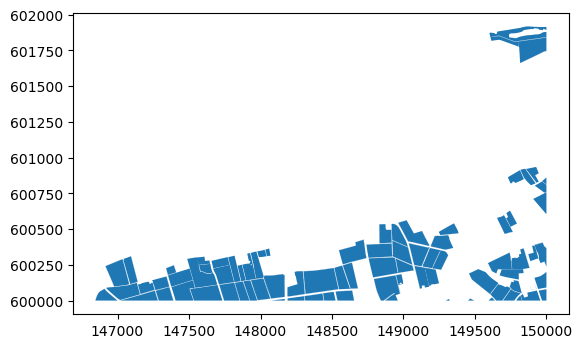

In [22]:
brp_clipped.plot()

In [23]:
transform = slope.rio.transform()

In [24]:
stats = zonal_stats(
    brp_clipped,
    slope.values,
    affine=transform,
    stats=["sum"],
    nodata=slope.rio.nodata if hasattr(slope, "rio") else None,
)

brp_clipped["raster_sum_ahn3"] = [s["sum"] for s in stats]

In [25]:
stats_brp_result = brp_clipped[["raster_sum_ahn3","uni_id"]]

In [26]:
stats_brp_result.head()

,raster_sum_ahn3,uni_id
198,459.556458,2137201
199,5679.913086,2096014
223,3723.235596,2076825
230,53531.375000,2092265
284,4647.648926,2155502


In [27]:
stats_brp_result.to_csv("result_csv//AHN3_"+ahn3_tif_name+".csv", index=False)